# Bitcoin Random Forest 2024 → 2025 Generalization Test

**Research Question:** Does the Random Forest trained on H1 2024 data generalize to 2025?

**Method:**
- Reconstruct the exact model from `btc_random_forest_2024.ipynb` (same H1 2024 training data, same hyperparameters from grid search)
- Evaluate out-of-sample on full calendar year 2025 (Jan–Dec 2025)
- Compare: predicted vs actual BTC forward returns (time series)
- Compare: simulated cumulative return from model signal vs buy-and-hold
- Compare metrics against H2 2024 baseline to assess generalization decay

**Note on model reconstruction:** The 2024 notebook did not serialize the fitted model to disk. This notebook reloads the exact same H1 2024 training data and refits with the exact hyperparameters (`max_depth=4`, `max_features='sqrt'`, `min_samples_leaf=8`, `n_estimators=200`, `random_state=42`) that emerged from the 2024 grid search. The result is bit-for-bit identical to the original model.

**Key 2025 events to watch:**
- Jan 2025: Trump inauguration — crypto-friendly executive orders
- Q1 2025: BTC peaks ~\$109K (Jan 20), then corrects sharply
- Mar–Apr 2025: Global trade war / tariff shock — risk-off selloff across markets
- Apr 2025: BTC rebounds toward \$95K on tariff pause signals

In [1]:
import os, sys, json, warnings
from datetime import datetime, timezone
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
from sqlalchemy import text

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv(project_root / '.env')
from etl.common.db.postgres import get_engine

engine = get_engine()

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams['font.size'] = 11
pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_columns', 60)
print('Setup complete.')

Setup complete.


In [2]:
# ── 2024 training window (must match btc_random_forest_2024 exactly)
STUDY_START  = '2023-01-01'   # warm-up data for rolling features
TRAIN_START  = '2024-01-01'
TRAIN_END    = '2024-06-30'
H2_TEST_START = '2024-07-01'
H2_TEST_END   = '2024-12-31'

# ── 2025 evaluation window
OOS_START = '2025-01-01'
OOS_END   = '2025-12-31'

# ── Exact hyperparameters from btc_random_forest_2024 grid search
BEST_PARAMS = {
    'max_depth':        4,
    'max_features':     'sqrt',
    'min_samples_leaf': 8,
    'n_estimators':     200,
    'random_state':     42,
    'n_jobs':           -1,
}

# ── Features used in the 2024 model (exact list)
FEAT_COLS = [
    'feat_btc_return_1d',
    'feat_btc_realized_vol_30d',
    'feat_sp500_return_1d',
    'feat_vix_close',
    'feat_gold_return_1d',
    'feat_dxy_index_return_1d',
    'feat_us_2y_treasury_yield',
    'feat_us_10y_treasury_yield',
    'feat_us_2s10s_spread_bps',
    'feat_us_2y_breakeven_inflation',
    'feat_move_index_close',
    'feat_commodity_index_return_1d',
    'feat_commodity_index_return_1d_roll_7d_mean',
    'feat_vix_close_roll_7d_mean',
    'z_feat_commodity_index_return_1d',
    'z_feat_us_2y_treasury_yield',
    'z_feat_us_10y_treasury_yield',
    'z_feat_vix_close',
    'z_feat_move_index_close',
    'feat_btc_return_lag_1',
    'feat_btc_return_lag_7',
    'feat_btc_etf_net_flow_usd_lag_1',
    'feat_btc_active_addresses_lag_1',
    'feat_btc_network_fees_native_lag_1',
]
TARGET_COL = 'target_btc_fwd_return_1d'

print(f'Training window  : {TRAIN_START} → {TRAIN_END}')
print(f'H2 2024 (in-sample OOS): {H2_TEST_START} → {H2_TEST_END}')
print(f'2025 evaluation  : {OOS_START} → {OOS_END}')
print(f'Features         : {len(FEAT_COLS)}')
print(f'Hyperparameters  : {BEST_PARAMS}')

Training window  : 2024-01-01 → 2024-06-30
H2 2024 (in-sample OOS): 2024-07-01 → 2024-12-31
2025 evaluation  : 2025-01-01 → 2025-12-31
Features         : 24
Hyperparameters  : {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'n_estimators': 200, 'random_state': 42, 'n_jobs': -1}


## 1. Reconstruct the 2024 Training Dataset

Load exactly what was used to train the 2024 model: H1 2024 features from `analytics.btc_model_features_daily` + targets from `analytics.btc_model_target_daily`.

In [3]:
def _q(sql, engine=engine):
    return pd.read_sql(text(sql), engine, parse_dates=['date_day'])

feat_cols_sql = ',\n            '.join(FEAT_COLS)

feat_2024 = _q(f"""
    SELECT DISTINCT ON (date_day)
        date_day,
        {feat_cols_sql},
        missing_feature_count
    FROM analytics.btc_model_features_daily
    WHERE date_day BETWEEN '{STUDY_START}' AND '{H2_TEST_END}'
    ORDER BY date_day, feature_asof_ts_utc DESC
""")

tgt_2024 = _q(f"""
    SELECT
        date_day,
        target_btc_close_usd,
        target_btc_fwd_return_1d,
        target_is_valid_for_training
    FROM analytics.btc_model_target_daily
    WHERE date_day BETWEEN '{STUDY_START}' AND '{H2_TEST_END}'
    ORDER BY date_day
""")

df_2024 = feat_2024.merge(tgt_2024, on='date_day', how='inner')
df_2024 = df_2024.sort_values('date_day').reset_index(drop=True)

print(f'Loaded 2024 dataset: {len(df_2024)} rows  |  {df_2024.date_day.min().date()} → {df_2024.date_day.max().date()}')
print(f'Missing feature count (mean): {df_2024.missing_feature_count.mean():.2f}')

Loaded 2024 dataset: 731 rows  |  2023-01-01 → 2024-12-31
Missing feature count (mean): 4.51


In [4]:
valid = df_2024[TARGET_COL].notna() & df_2024['target_is_valid_for_training'].astype(bool)

train_mask = (df_2024['date_day'] >= TRAIN_START) & (df_2024['date_day'] <= TRAIN_END)
h2_mask    = (df_2024['date_day'] >= H2_TEST_START) & (df_2024['date_day'] <= H2_TEST_END)

train_df = df_2024[train_mask & valid].copy()
h2_df    = df_2024[h2_mask   & valid].copy()

# Drop rows with too many NaN features (rolling warm-up)
train_df = train_df.dropna(subset=FEAT_COLS, thresh=int(len(FEAT_COLS) * 0.7))
h2_df    = h2_df.dropna(subset=FEAT_COLS,   thresh=int(len(FEAT_COLS) * 0.7))

# Impute remaining NaNs using training set medians
feat_medians = train_df[FEAT_COLS].median()
train_df[FEAT_COLS] = train_df[FEAT_COLS].fillna(feat_medians)
h2_df[FEAT_COLS]    = h2_df[FEAT_COLS].fillna(feat_medians)

X_train  = train_df[FEAT_COLS].values
y_train  = train_df[TARGET_COL].values
X_h2     = h2_df[FEAT_COLS].values
y_h2     = h2_df[TARGET_COL].values

print(f'H1 2024 training rows : {len(X_train)}')
print(f'H2 2024 benchmark rows: {len(X_h2)}')

H1 2024 training rows : 182
H2 2024 benchmark rows: 184


## 2. Fit the 2024 Model

Fit with the exact hyperparameters from the 2024 grid search. `random_state=42` ensures the tree structure is deterministic.

In [5]:
model = RandomForestRegressor(**BEST_PARAMS)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_h2    = model.predict(X_h2)

def metrics(y_true, y_pred, label=''):
    r2  = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    diracc = ((y_true > 0) == (y_pred > 0)).mean()
    return {'Period': label, 'R²': r2, 'RMSE': rmse, 'MAE': mae, 'Dir Acc': diracc, 'N': len(y_true)}

m_train = metrics(y_train, y_pred_train, 'H1 2024 (train)')
m_h2    = metrics(y_h2,    y_pred_h2,    'H2 2024 (OOS baseline)')

print('Model fitted. In-sample + H2 2024 baseline metrics:')
print(pd.DataFrame([m_train, m_h2]).set_index('Period').to_string())

Model fitted. In-sample + H2 2024 baseline metrics:
                              R²     RMSE      MAE  Dir Acc    N
Period                                                          
H1 2024 (train)         0.243300 0.023402 0.017231 0.686813  182
H2 2024 (OOS baseline) -0.018843 0.025912 0.019516 0.489130  184


## 3. Load 2025 Data and Predict

In [6]:
# Check availability
avail = pd.read_sql(text(f"""
    SELECT
        (SELECT COUNT(*) FROM analytics.btc_model_features_daily
         WHERE date_day BETWEEN '{OOS_START}' AND '{OOS_END}') AS feat_rows,
        (SELECT COUNT(*) FROM analytics.btc_model_target_daily
         WHERE date_day BETWEEN '{OOS_START}' AND '{OOS_END}') AS tgt_rows,
        (SELECT MAX(date_day)::text FROM analytics.btc_model_features_daily
         WHERE date_day BETWEEN '{OOS_START}' AND '{OOS_END}') AS feat_max_date,
        (SELECT MAX(date_day)::text FROM analytics.btc_model_target_daily
         WHERE date_day BETWEEN '{OOS_START}' AND '{OOS_END}') AS tgt_max_date
"""), engine).iloc[0]

print(f"Feature rows in 2025 : {avail['feat_rows']}  (through {avail['feat_max_date']})")
print(f"Target rows in 2025  : {avail['tgt_rows']}  (through {avail['tgt_max_date']})")

feat_2025 = _q(f"""
    SELECT DISTINCT ON (date_day)
        date_day,
        {feat_cols_sql},
        missing_feature_count
    FROM analytics.btc_model_features_daily
    WHERE date_day BETWEEN '{OOS_START}' AND '{OOS_END}'
    ORDER BY date_day, feature_asof_ts_utc DESC
""")

tgt_2025 = _q(f"""
    SELECT
        date_day,
        target_btc_close_usd,
        target_btc_fwd_return_1d,
        target_is_valid_for_training
    FROM analytics.btc_model_target_daily
    WHERE date_day BETWEEN '{OOS_START}' AND '{OOS_END}'
    ORDER BY date_day
"""
)

df_2025 = feat_2025.merge(tgt_2025, on='date_day', how='inner')
df_2025 = df_2025.sort_values('date_day').reset_index(drop=True)

valid_2025 = df_2025[TARGET_COL].notna() & df_2025['target_is_valid_for_training'].astype(bool)
oos_df = df_2025[valid_2025].copy()

# Apply training-set medians for imputation (same as 2024 notebook)
oos_df[FEAT_COLS] = oos_df[FEAT_COLS].fillna(feat_medians)

X_oos = oos_df[FEAT_COLS].values
y_oos = oos_df[TARGET_COL].values

print(f'\n2025 evaluation rows : {len(oos_df)}')
print(f'Date range           : {oos_df.date_day.min().date()} → {oos_df.date_day.max().date()}')

Feature rows in 2025 : 365  (through 2025-12-31)
Target rows in 2025  : 365  (through 2025-12-31)

2025 evaluation rows : 365
Date range           : 2025-01-01 → 2025-12-31


In [7]:
y_pred_oos = model.predict(X_oos)

oos_df = oos_df.copy()
oos_df['predicted']        = y_pred_oos
oos_df['actual']           = y_oos
oos_df['residual']         = y_oos - y_pred_oos
oos_df['pred_direction']   = (y_pred_oos > 0).astype(int)
oos_df['actual_direction'] = (y_oos > 0).astype(int)
oos_df['direction_correct'] = (oos_df['pred_direction'] == oos_df['actual_direction'])

m_oos = metrics(y_oos, y_pred_oos, '2025 (true OOS)')

print('Performance comparison:')
results_df = pd.DataFrame([m_train, m_h2, m_oos]).set_index('Period')
print(results_df.round(4).to_string())

Performance comparison:
                              R²     RMSE      MAE  Dir Acc    N
Period                                                          
H1 2024 (train)         0.243300 0.023400 0.017200 0.686800  182
H2 2024 (OOS baseline) -0.018800 0.025900 0.019500 0.489100  184
2025 (true OOS)        -0.041200 0.021900 0.016100 0.504100  365


## 4. Time Series: Actual vs Predicted Forward Returns

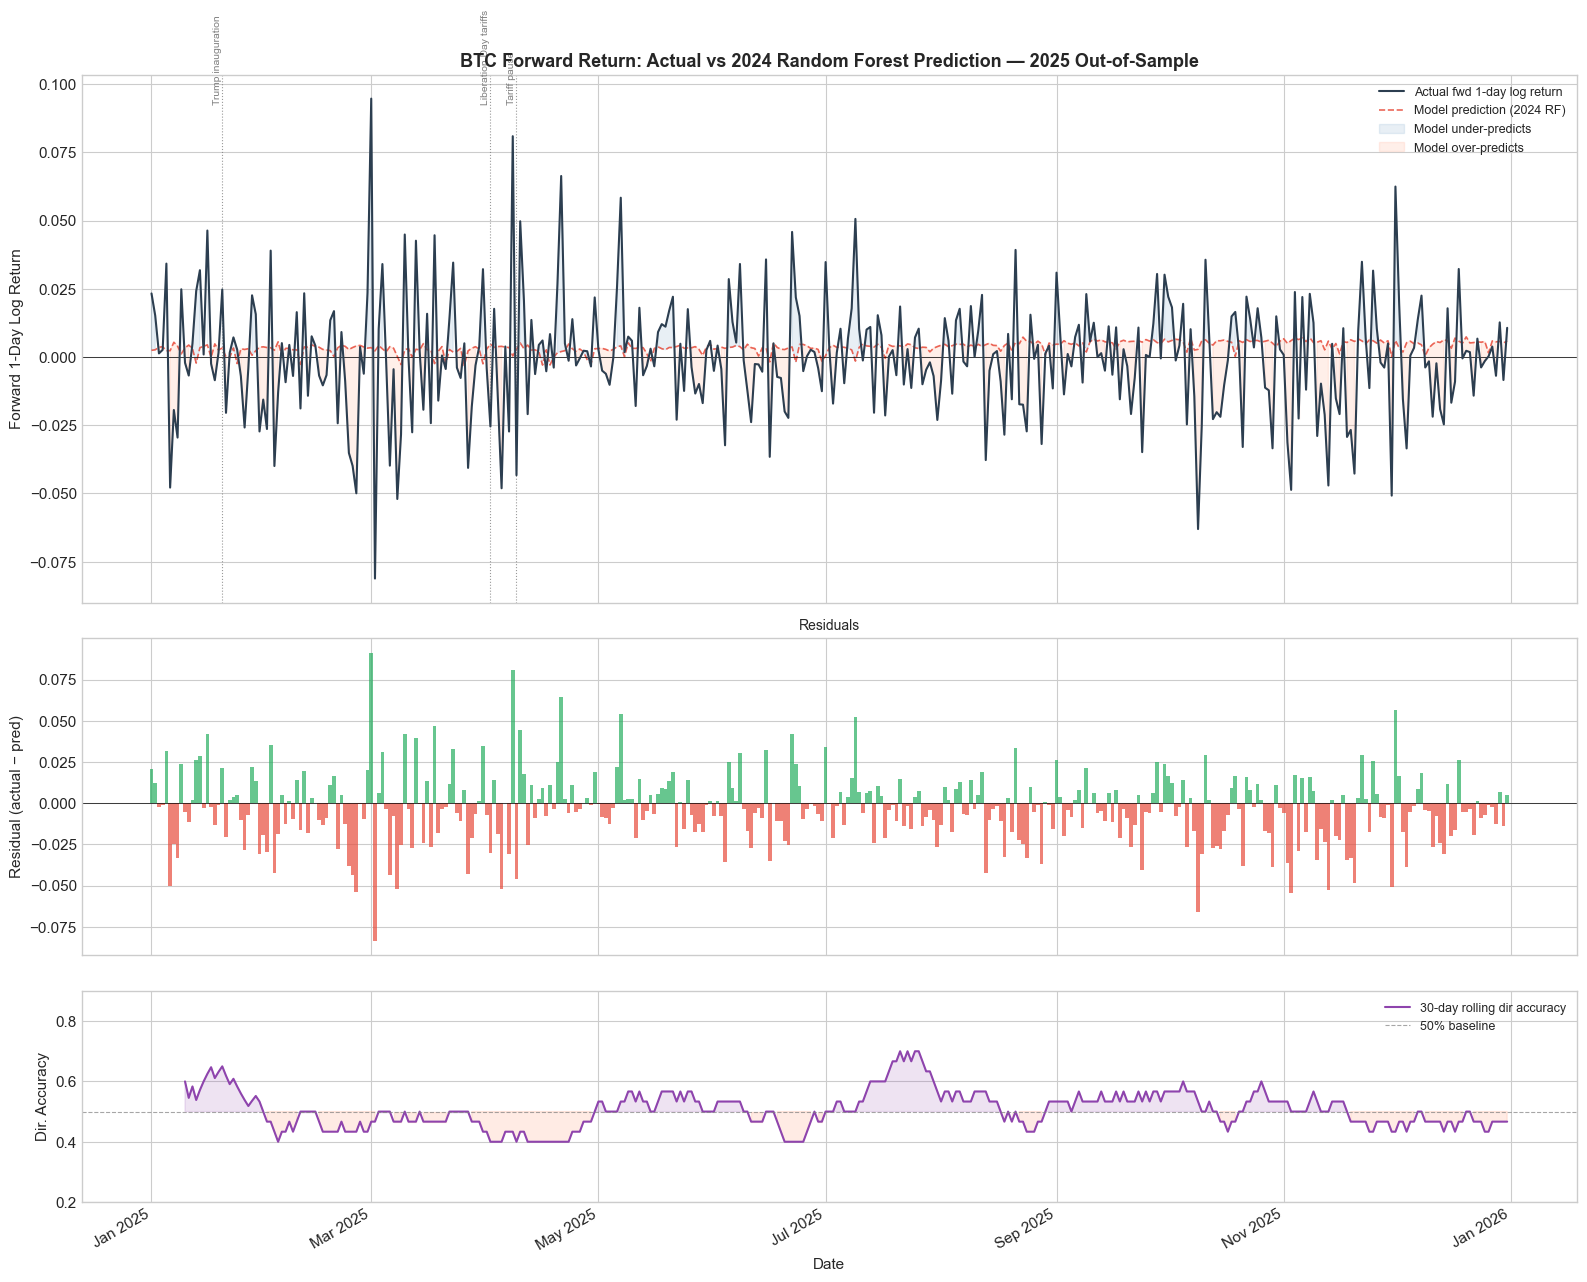

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 1.5, 1]})

dates = oos_df['date_day']

# ── Panel 1: Actual vs predicted forward returns
ax = axes[0]
ax.plot(dates, oos_df['actual'],    color='#2c3e50', lw=1.5, label='Actual fwd 1-day log return', zorder=3)
ax.plot(dates, oos_df['predicted'], color='#e74c3c', lw=1.2, ls='--', alpha=0.85,
        label='Model prediction (2024 RF)', zorder=2)
ax.fill_between(dates, oos_df['actual'], oos_df['predicted'],
                where=oos_df['actual'] >= oos_df['predicted'],
                alpha=0.12, color='steelblue', label='Model under-predicts')
ax.fill_between(dates, oos_df['actual'], oos_df['predicted'],
                where=oos_df['actual'] < oos_df['predicted'],
                alpha=0.12, color='coral',     label='Model over-predicts')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Forward 1-Day Log Return')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('BTC Forward Return: Actual vs 2024 Random Forest Prediction — 2025 Out-of-Sample',
             fontweight='bold', fontsize=13)

for event_date, label in [
    ('2025-01-20', 'Trump inauguration'),
    ('2025-04-02', 'Liberation Day tariffs'),
    ('2025-04-09', 'Tariff pause'),
]:
    if pd.Timestamp(event_date) <= dates.max():
        ax.axvline(pd.Timestamp(event_date), color='gray', lw=0.8, ls=':', alpha=0.8)
        ax.text(pd.Timestamp(event_date),
                ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 0.05,
                label, fontsize=7.5, rotation=90, ha='right', color='gray')

# ── Panel 2: Residuals
ax2 = axes[1]
colors_res = ['#27ae60' if r >= 0 else '#e74c3c' for r in oos_df['residual']]
ax2.bar(dates, oos_df['residual'], color=colors_res, width=1.0, alpha=0.7)
ax2.axhline(0, color='black', lw=0.5)
ax2.set_ylabel('Residual (actual − pred)')
ax2.set_title('Residuals', fontsize=10)

# ── Panel 3: Directional accuracy (30-day rolling)
ax3 = axes[2]
rolling_diracc = oos_df['direction_correct'].astype(float).rolling(30, min_periods=10).mean()
ax3.plot(dates, rolling_diracc, color='#8e44ad', lw=1.5, label='30-day rolling dir accuracy')
ax3.axhline(0.5, color='gray', lw=0.8, ls='--', alpha=0.7, label='50% baseline')
ax3.fill_between(dates, 0.5, rolling_diracc,
                 where=rolling_diracc >= 0.5, alpha=0.15, color='#8e44ad')
ax3.fill_between(dates, 0.5, rolling_diracc,
                 where=rolling_diracc < 0.5,  alpha=0.15, color='coral')
ax3.set_ylim(0.2, 0.9)
ax3.set_ylabel('Dir. Accuracy')
ax3.legend(fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.set_xlabel('Date')

plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. BTC Price: Actual vs Model-Implied Price Path

Reconstruct the implied price level from cumulative predicted log returns, anchored to the actual BTC price on 2025-01-01. This shows whether the model's directional signals, compounded over the year, track the real price trajectory.

Anchor price (2025-01-01): $94,596


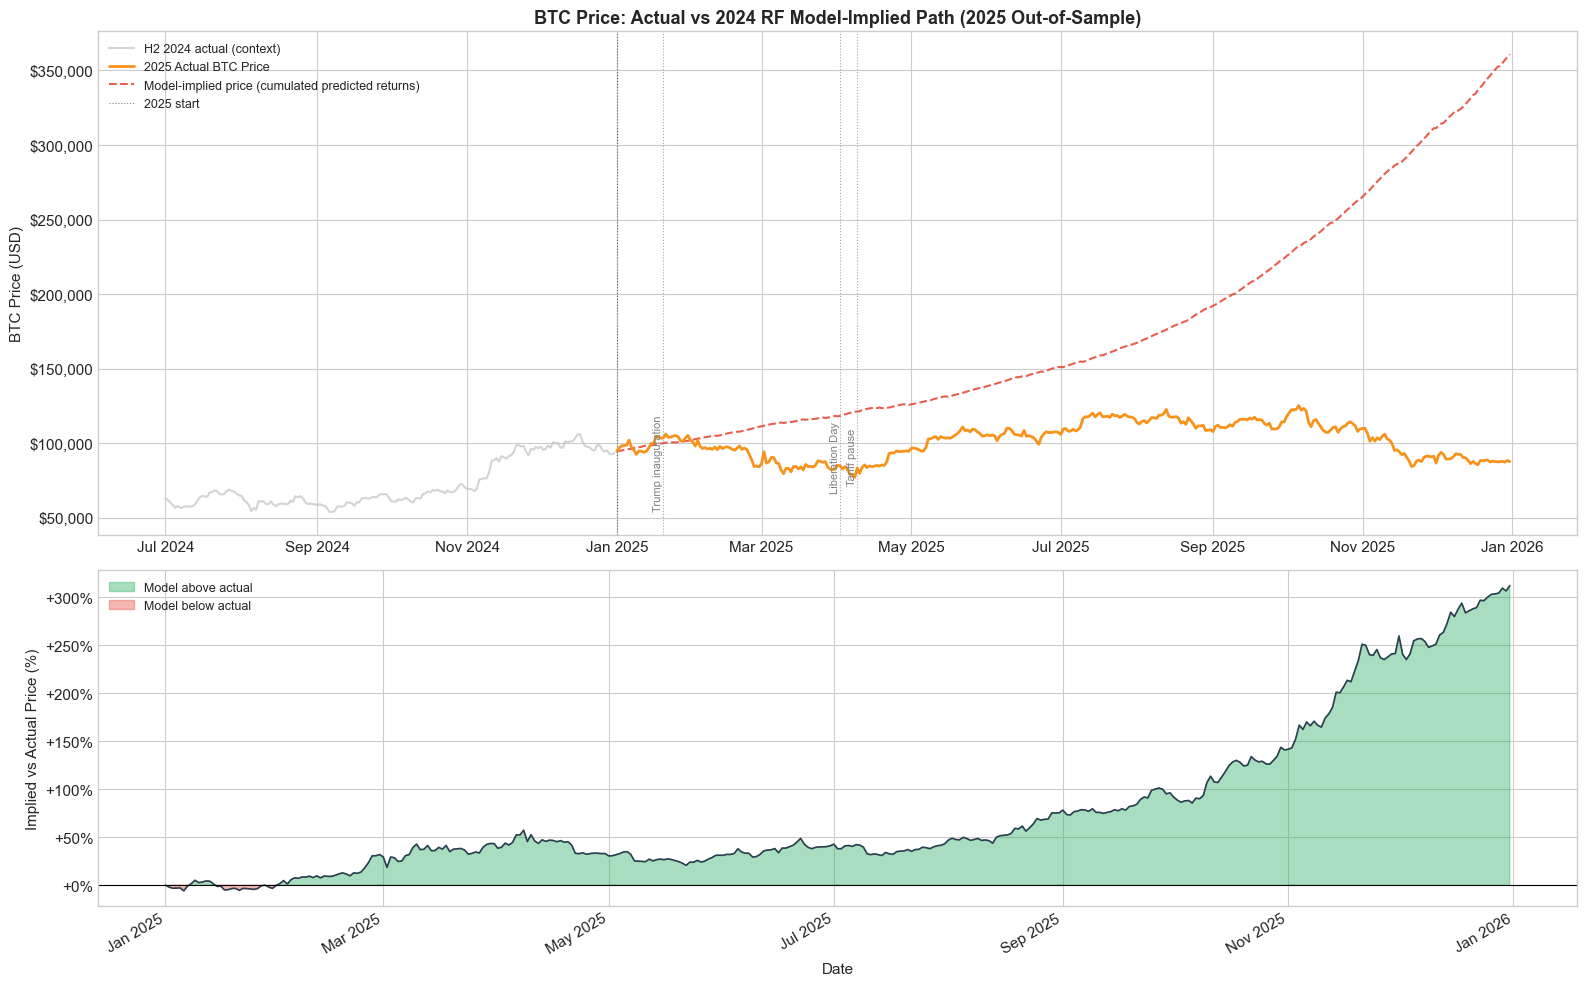

Final implied price : $360,866
Final actual price  : $87,591


In [9]:
# Actual BTC price from target table
btc_price = oos_df[['date_day', 'target_btc_close_usd']].copy()
btc_price = btc_price.dropna(subset=['target_btc_close_usd'])

# Also load actual H2 2024 prices for context
price_context = _q(f"""
    SELECT date_day, btc_close_usd
    FROM analytics.btc_market_daily
    WHERE date_day BETWEEN '2024-07-01' AND '{OOS_END}'
    ORDER BY date_day
""")

# Reconstruct implied price path from predicted forward returns
# Forward return on day t = log(price_t+1 / price_t)
# So predicted price_t+1 = price_t * exp(predicted_fwd_return_t)
anchor_price = btc_price['target_btc_close_usd'].iloc[0]  # Jan 1 2025
print(f'Anchor price (2025-01-01): ${anchor_price:,.0f}')

implied_prices = [anchor_price]
for i in range(len(oos_df) - 1):
    pred_return = oos_df['predicted'].iloc[i]
    implied_prices.append(implied_prices[-1] * np.exp(pred_return))

oos_df['implied_price'] = implied_prices

# ── Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False,
                         gridspec_kw={'height_ratios': [3, 2]})

# Panel 1: Full price path (H2 2024 context + 2025)
ax1 = axes[0]

# H2 2024 actual (context)
h2_price = price_context[price_context['date_day'] < '2025-01-01']
ax1.plot(h2_price['date_day'], h2_price['btc_close_usd'],
         color='#bdc3c7', lw=1.5, alpha=0.7, label='H2 2024 actual (context)')

# 2025 actual
ax1.plot(btc_price['date_day'], btc_price['target_btc_close_usd'],
         color='#F7931A', lw=2.0, label='2025 Actual BTC Price', zorder=3)

# Model-implied price
ax1.plot(oos_df['date_day'], oos_df['implied_price'],
         color='#e74c3c', lw=1.5, ls='--', alpha=0.9,
         label='Model-implied price (cumulated predicted returns)', zorder=2)

ax1.axvline(pd.Timestamp('2025-01-01'), color='black', lw=0.8, ls=':', alpha=0.5, label='2025 start')

for event_date, label, ypos_frac in [
    ('2025-01-20', 'Trump inauguration', 0.95),
    ('2025-04-02', 'Liberation Day', 0.92),
    ('2025-04-09', 'Tariff pause', 0.88),
]:
    if pd.Timestamp(event_date) <= oos_df['date_day'].max():
        ax1.axvline(pd.Timestamp(event_date), color='gray', lw=0.8, ls=':', alpha=0.7)
        ymax = price_context['btc_close_usd'].max()
        ax1.text(pd.Timestamp(event_date), ymax * ypos_frac,
                 label, fontsize=8, rotation=90, ha='right', color='gray', va='top')

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.set_ylabel('BTC Price (USD)')
ax1.legend(loc='upper left', fontsize=9)
ax1.set_title('BTC Price: Actual vs 2024 RF Model-Implied Path (2025 Out-of-Sample)',
              fontweight='bold', fontsize=13)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Panel 2: Percentage divergence between implied and actual price
ax2 = axes[1]
merged = oos_df[['date_day', 'implied_price']].merge(
    btc_price[['date_day', 'target_btc_close_usd']], on='date_day', how='inner'
)
pct_error = (merged['implied_price'] - merged['target_btc_close_usd']) / merged['target_btc_close_usd'] * 100

ax2.fill_between(merged['date_day'], 0, pct_error,
                 where=pct_error >= 0, alpha=0.4, color='#27ae60', label='Model above actual')
ax2.fill_between(merged['date_day'], 0, pct_error,
                 where=pct_error < 0,  alpha=0.4, color='#e74c3c', label='Model below actual')
ax2.plot(merged['date_day'], pct_error, color='#2c3e50', lw=1.2)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('Implied vs Actual Price (%)' )
ax2.set_xlabel('Date')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

print(f'Final implied price : ${oos_df["implied_price"].iloc[-1]:,.0f}')
print(f'Final actual price  : ${btc_price["target_btc_close_usd"].iloc[-1]:,.0f}')

## 6. Performance Dashboard — 2025 vs H2 2024 Baseline

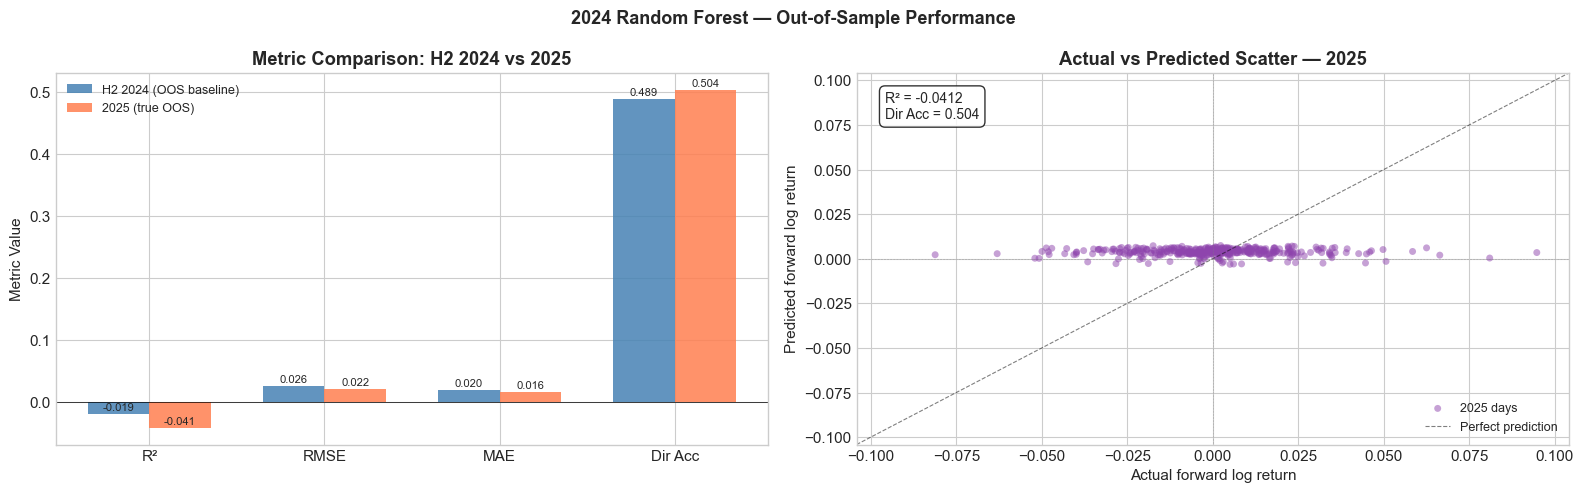


Full metrics table:
                              R²     RMSE      MAE  Dir Acc    N
Period                                                          
H1 2024 (train)         0.243300 0.023400 0.017200 0.686800  182
H2 2024 (OOS baseline) -0.018800 0.025900 0.019500 0.489100  184
2025 (true OOS)        -0.041200 0.021900 0.016100 0.504100  365


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: Metrics bar chart
ax_bar = axes[0]
metric_names = ['R²', 'RMSE', 'MAE', 'Dir Acc']
h2_vals  = [m_h2[k]  for k in metric_names]
oos_vals = [m_oos[k] for k in metric_names]

x = np.arange(len(metric_names))
w = 0.35
bars1 = ax_bar.bar(x - w/2, h2_vals,  w, label='H2 2024 (OOS baseline)', color='steelblue', alpha=0.85)
bars2 = ax_bar.bar(x + w/2, oos_vals, w, label='2025 (true OOS)',         color='coral',     alpha=0.85)

for bar in bars1 + bars2:
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width() / 2, h + 0.002, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8)

ax_bar.axhline(0, color='black', lw=0.5)
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(metric_names)
ax_bar.set_title('Metric Comparison: H2 2024 vs 2025', fontweight='bold')
ax_bar.legend(fontsize=9)
ax_bar.set_ylabel('Metric Value')

# ── Right: Scatter actual vs predicted (2025)
ax_sc = axes[1]
ax_sc.scatter(oos_df['actual'], oos_df['predicted'],
              alpha=0.5, s=25, color='#8e44ad', edgecolors='none', label='2025 days')
lim = max(abs(oos_df['actual'].max()), abs(oos_df['actual'].min()),
          abs(oos_df['predicted'].max()), abs(oos_df['predicted'].min())) * 1.1
ax_sc.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, alpha=0.5, label='Perfect prediction')
ax_sc.axhline(0, color='gray', lw=0.4, ls=':')
ax_sc.axvline(0, color='gray', lw=0.4, ls=':')
ax_sc.set_xlim(-lim, lim)
ax_sc.set_ylim(-lim, lim)
ax_sc.set_xlabel('Actual forward log return')
ax_sc.set_ylabel('Predicted forward log return')
ax_sc.set_title('Actual vs Predicted Scatter — 2025', fontweight='bold')
r2_text = f"R² = {m_oos['R²']:.4f}\nDir Acc = {m_oos['Dir Acc']:.3f}"
ax_sc.text(0.04, 0.95, r2_text, transform=ax_sc.transAxes, fontsize=10,
           va='top', bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.8))
ax_sc.legend(fontsize=9)

plt.suptitle('2024 Random Forest — Out-of-Sample Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nFull metrics table:')
print(results_df.round(4).to_string())

## 7. Cumulative Return — Model Signal vs Buy-and-Hold

Simulate a long/short strategy:
- **Long** when model predicts positive return
- **Short** (or flat) when model predicts negative return
- Compare against buy-and-hold BTC

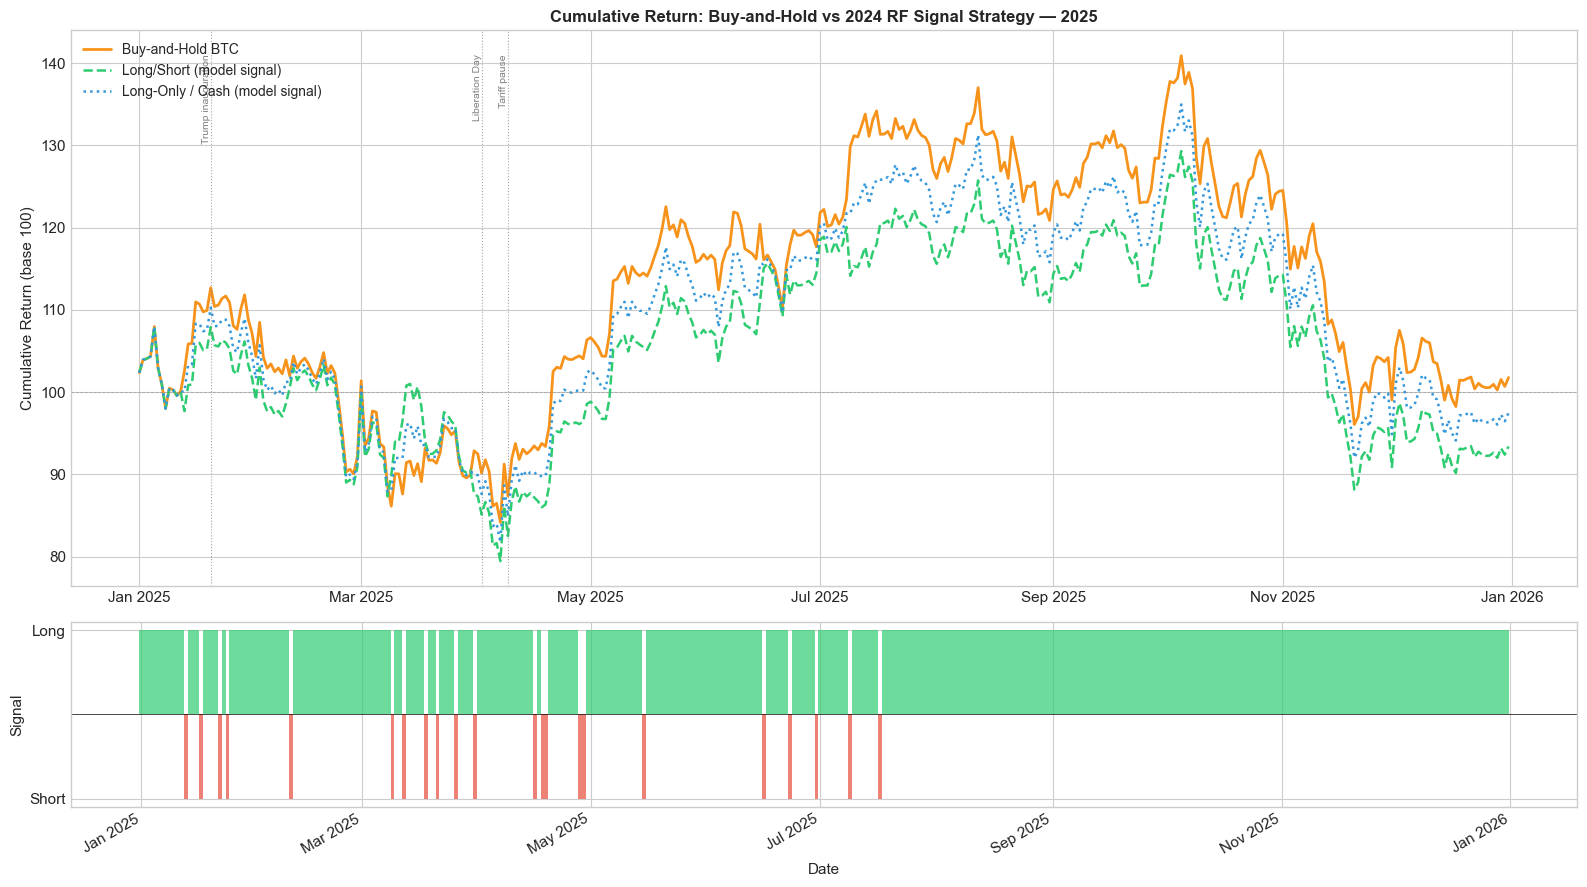

Buy-and-Hold return   : +1.8%
Long/Short return     : -6.6%
Long-Only/Cash return : -2.5%
Fraction of days long : 94.0%


In [11]:
oos_df = oos_df.copy()

# Long/short: +1 when model predicts up, -1 when model predicts down
oos_df['signal_ls']   = np.where(oos_df['predicted'] > 0, 1, -1)
# Long-only: +1 when model predicts up, 0 (flat/cash) when model predicts down
oos_df['signal_lo']   = np.where(oos_df['predicted'] > 0, 1, 0)

# Strategy return = signal * actual return (no transaction costs)
oos_df['ret_ls']      = oos_df['signal_ls']   * oos_df['actual']
oos_df['ret_lo']      = oos_df['signal_lo']   * oos_df['actual']
oos_df['ret_bnh']     = oos_df['actual']  # buy-and-hold

# Cumulative log returns → index (base 100)
cum_ls  = 100 * np.exp(oos_df['ret_ls'].cumsum())
cum_lo  = 100 * np.exp(oos_df['ret_lo'].cumsum())
cum_bnh = 100 * np.exp(oos_df['ret_bnh'].cumsum())

fig, axes = plt.subplots(2, 1, figsize=(16, 9),
                         gridspec_kw={'height_ratios': [3, 1]})

ax1 = axes[0]
ax1.plot(oos_df['date_day'], cum_bnh, color='#F7931A', lw=2.0, label='Buy-and-Hold BTC')
ax1.plot(oos_df['date_day'], cum_ls,  color='#2ecc71', lw=1.8, ls='--', label='Long/Short (model signal)')
ax1.plot(oos_df['date_day'], cum_lo,  color='#3498db', lw=1.8, ls=':',  label='Long-Only / Cash (model signal)')
ax1.axhline(100, color='gray', lw=0.6, ls='--', alpha=0.5)

for event_date, label in [
    ('2025-01-20', 'Trump inauguration'),
    ('2025-04-02', 'Liberation Day'),
    ('2025-04-09', 'Tariff pause'),
]:
    if pd.Timestamp(event_date) <= oos_df['date_day'].max():
        ax1.axvline(pd.Timestamp(event_date), color='gray', lw=0.8, ls=':', alpha=0.7)
        ax1.text(pd.Timestamp(event_date),
                 ax1.get_ylim()[1] * 0.98 if ax1.get_ylim()[1] > 0 else 110,
                 label, fontsize=7.5, rotation=90, ha='right', color='gray', va='top')

ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}'))
ax1.set_ylabel('Cumulative Return (base 100)')
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Cumulative Return: Buy-and-Hold vs 2024 RF Signal Strategy — 2025',
              fontweight='bold', fontsize=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Panel 2: Daily signal
ax2 = axes[1]
sig_colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in oos_df['signal_ls']]
ax2.bar(oos_df['date_day'], oos_df['signal_ls'], color=sig_colors, width=1.0, alpha=0.7)
ax2.axhline(0, color='black', lw=0.5)
ax2.set_yticks([-1, 1])
ax2.set_yticklabels(['Short', 'Long'])
ax2.set_ylabel('Signal')
ax2.set_xlabel('Date')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.show()

final_bnh = cum_bnh.iloc[-1]
final_ls  = cum_ls.iloc[-1]
final_lo  = cum_lo.iloc[-1]
long_frac = (oos_df['signal_ls'] == 1).mean()
print(f'Buy-and-Hold return   : {final_bnh - 100:+.1f}%')
print(f'Long/Short return     : {final_ls  - 100:+.1f}%')
print(f'Long-Only/Cash return : {final_lo  - 100:+.1f}%')
print(f'Fraction of days long : {long_frac:.1%}')

## 8. Monthly Breakdown — Directional Accuracy and Return Contribution

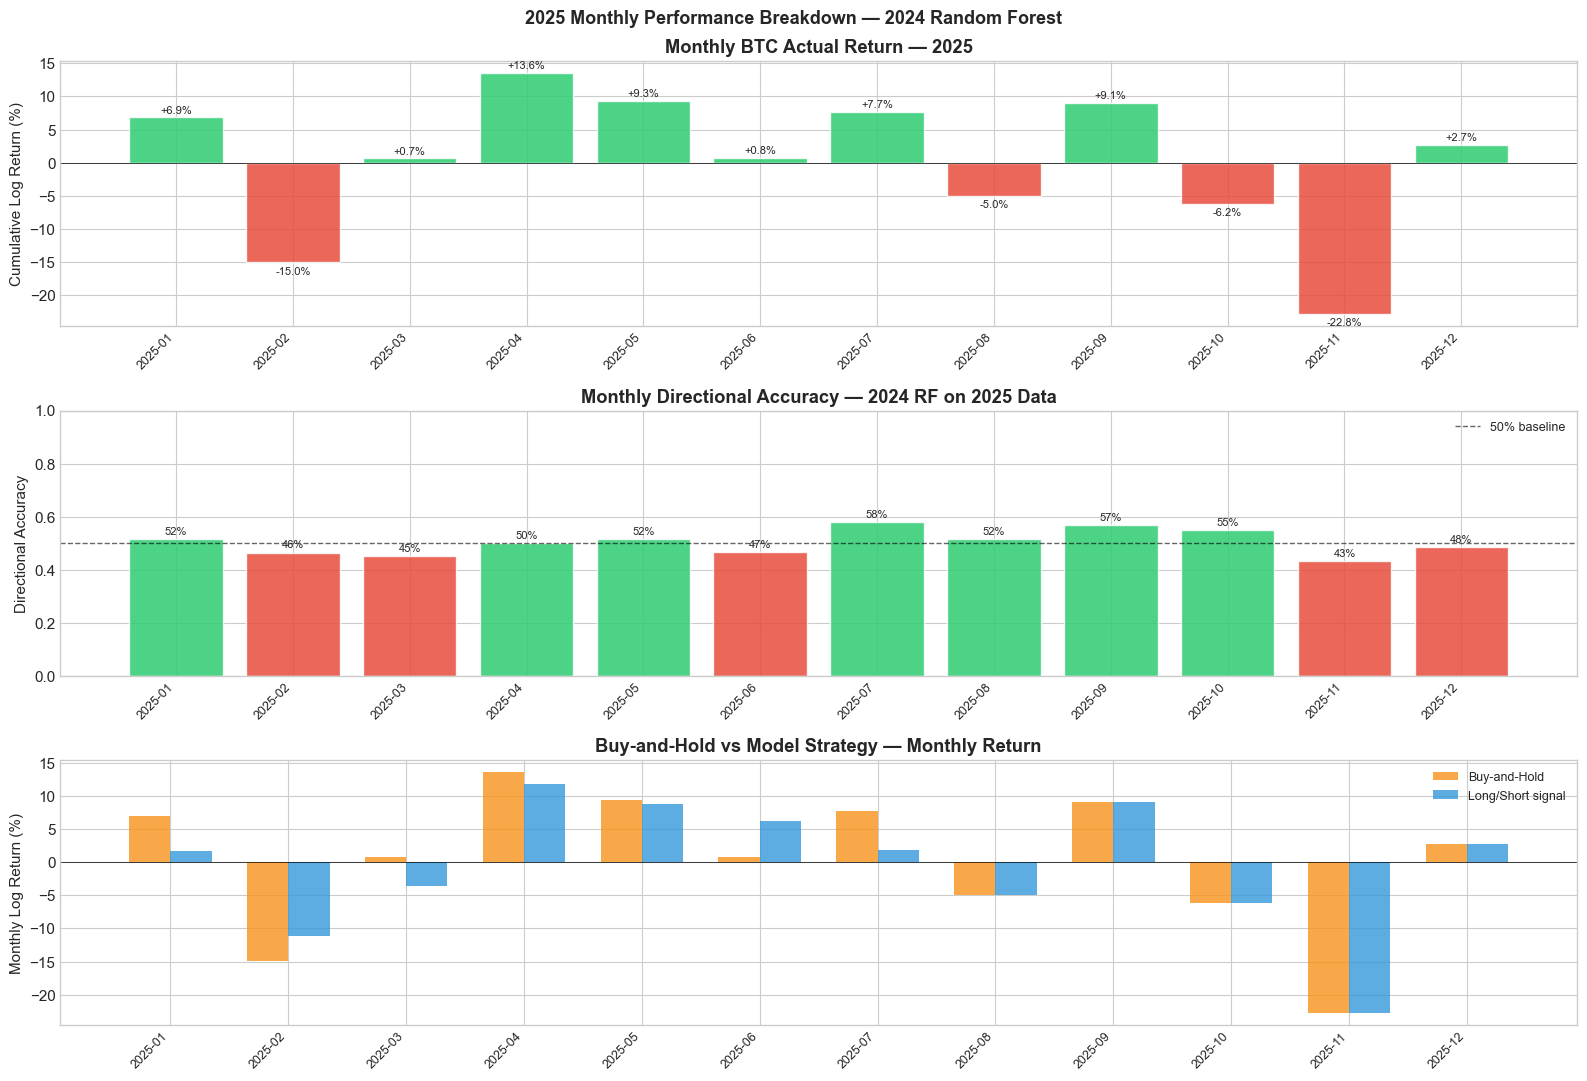


Monthly summary:
  Month  Days  Actual Ret  Dir Acc  Pct Long    LS Ret
2025-01    31    0.068827 0.516129  0.870968  0.016753
2025-02    28   -0.149850 0.464286  0.964286 -0.112131
2025-03    31    0.006956 0.451613  0.806452 -0.036112
2025-04    30    0.135563 0.500000  0.833333  0.117082
2025-05    31    0.093354 0.516129  0.967742  0.087255
2025-06    30    0.007783 0.466667  0.900000  0.062292
2025-07    31    0.076860 0.580645  0.935484  0.018452
2025-08    31   -0.050022 0.516129  1.000000 -0.050022
2025-09    30    0.090602 0.566667  1.000000  0.090602
2025-10    31   -0.061667 0.548387  1.000000 -0.061667
2025-11    30   -0.228064 0.433333  1.000000 -0.228064
2025-12    31    0.027176 0.483871  1.000000  0.027176


In [12]:
oos_df['month'] = oos_df['date_day'].dt.to_period('M')

monthly = oos_df.groupby('month').agg(
    n_days           = ('actual', 'count'),
    actual_ret       = ('actual', 'sum'),
    dir_accuracy     = ('direction_correct', 'mean'),
    abs_error_mean   = ('residual', lambda x: np.abs(x).mean()),
    pct_days_long    = ('signal_ls', lambda x: (x == 1).mean()),
    strategy_ret_ls  = ('ret_ls',  'sum'),
).reset_index()
monthly['month_str'] = monthly['month'].astype(str)

fig, axes = plt.subplots(3, 1, figsize=(16, 11))

months = monthly['month_str']
x = np.arange(len(months))

# Panel 1: Actual monthly log return
ax1 = axes[0]
bar_colors = ['#2ecc71' if r >= 0 else '#e74c3c' for r in monthly['actual_ret']]
ax1.bar(x, monthly['actual_ret'] * 100, color=bar_colors, alpha=0.85, edgecolor='white')
ax1.axhline(0, color='black', lw=0.5)
ax1.set_xticks(x)
ax1.set_xticklabels(months, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Cumulative Log Return (%)')
ax1.set_title('Monthly BTC Actual Return — 2025', fontweight='bold')
for i, v in enumerate(monthly['actual_ret']):
    ax1.text(i, v * 100 + (0.3 if v >= 0 else -0.6), f'{v*100:+.1f}%',
             ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)

# Panel 2: Monthly directional accuracy
ax2 = axes[1]
bar_colors2 = ['#2ecc71' if d >= 0.5 else '#e74c3c' for d in monthly['dir_accuracy']]
ax2.bar(x, monthly['dir_accuracy'], color=bar_colors2, alpha=0.85, edgecolor='white')
ax2.axhline(0.5, color='black', lw=1.0, ls='--', alpha=0.6, label='50% baseline')
ax2.set_ylim(0, 1)
ax2.set_xticks(x)
ax2.set_xticklabels(months, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Directional Accuracy')
ax2.set_title('Monthly Directional Accuracy — 2024 RF on 2025 Data', fontweight='bold')
ax2.legend(fontsize=9)
for i, v in enumerate(monthly['dir_accuracy']):
    ax2.text(i, v + 0.01, f'{v:.0%}', ha='center', va='bottom', fontsize=8)

# Panel 3: Long/short vs buy-and-hold monthly return
ax3 = axes[2]
w = 0.35
ax3.bar(x - w/2, monthly['actual_ret'] * 100,       w, label='Buy-and-Hold', color='#F7931A', alpha=0.8)
ax3.bar(x + w/2, monthly['strategy_ret_ls'] * 100,  w, label='Long/Short signal', color='#3498db', alpha=0.8)
ax3.axhline(0, color='black', lw=0.5)
ax3.set_xticks(x)
ax3.set_xticklabels(months, rotation=45, ha='right', fontsize=9)
ax3.set_ylabel('Monthly Log Return (%)')
ax3.set_title('Buy-and-Hold vs Model Strategy — Monthly Return', fontweight='bold')
ax3.legend(fontsize=9)

plt.suptitle('2025 Monthly Performance Breakdown — 2024 Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nMonthly summary:')
disp = monthly[['month_str', 'n_days', 'actual_ret', 'dir_accuracy', 'pct_days_long', 'strategy_ret_ls']].copy()
disp.columns = ['Month', 'Days', 'Actual Ret', 'Dir Acc', 'Pct Long', 'LS Ret']
print(disp.to_string(index=False))

## 9. Feature Importance Stability — 2024 Training vs 2025 Permutation

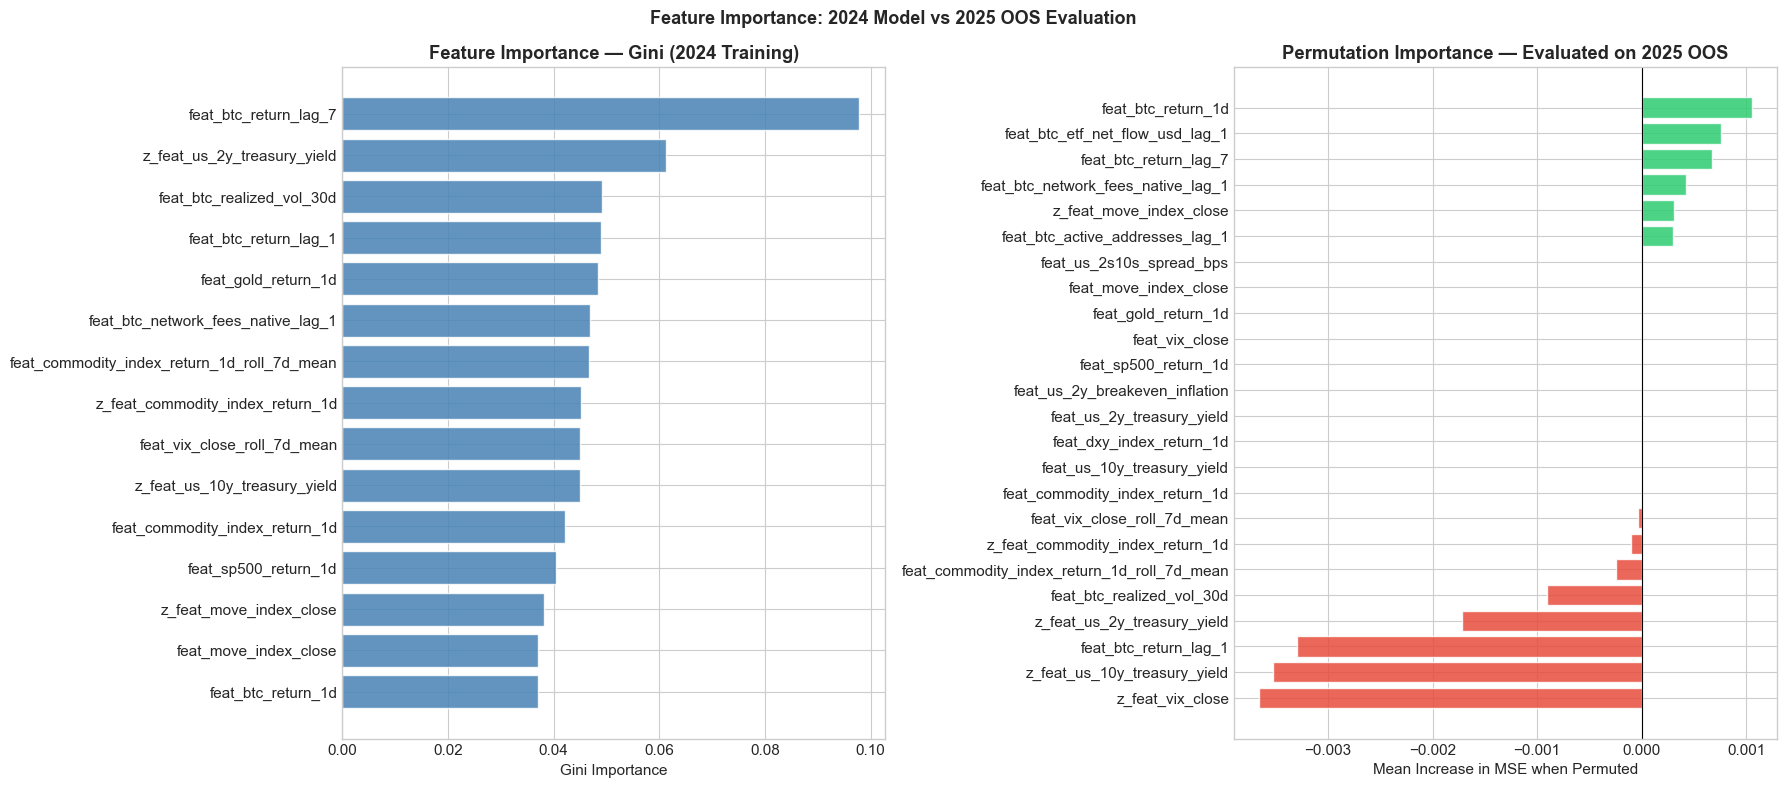


Top 10 features by 2025 permutation importance:
feat_btc_return_1d                   0.001060
feat_btc_etf_net_flow_usd_lag_1      0.000764
feat_btc_return_lag_7                0.000678
feat_btc_network_fees_native_lag_1   0.000423
z_feat_move_index_close              0.000311
feat_btc_active_addresses_lag_1      0.000306
feat_vix_close                       0.000000
feat_sp500_return_1d                 0.000000
feat_commodity_index_return_1d       0.000000
feat_us_10y_treasury_yield           0.000000

Bottom 5 features (reduced importance in 2025):
z_feat_vix_close               -0.003661
z_feat_us_10y_treasury_yield   -0.003525
feat_btc_return_lag_1          -0.003301
z_feat_us_2y_treasury_yield    -0.001721
feat_btc_realized_vol_30d      -0.000906


In [13]:
perm = permutation_importance(model, X_oos, y_oos, n_repeats=20, random_state=42, n_jobs=-1)

gini_imp  = pd.Series(model.feature_importances_, index=FEAT_COLS)
perm_imp  = pd.Series(perm.importances_mean,       index=FEAT_COLS)

compare = pd.DataFrame({
    'Gini (2024 training)': gini_imp,
    'Permutation (2025 OOS)': perm_imp,
}).sort_values('Gini (2024 training)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Gini (training)
top_n = compare.head(15)
top_n_sorted = top_n.sort_values('Gini (2024 training)', ascending=True)
axes[0].barh(top_n_sorted.index, top_n_sorted['Gini (2024 training)'],
             color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_xlabel('Gini Importance')
axes[0].set_title('Feature Importance — Gini (2024 Training)', fontweight='bold')

# Right: Permutation on 2025 OOS
perm_sorted = perm_imp.sort_values(ascending=True)
bar_colors_perm = ['#2ecc71' if v > 0 else '#e74c3c' for v in perm_sorted]
axes[1].barh(perm_sorted.index, perm_sorted, color=bar_colors_perm, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Mean Increase in MSE when Permuted')
axes[1].set_title('Permutation Importance — Evaluated on 2025 OOS', fontweight='bold')

plt.suptitle('Feature Importance: 2024 Model vs 2025 OOS Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 10 features by 2025 permutation importance:')
print(perm_imp.sort_values(ascending=False).head(10).round(6).to_string())

print('\nBottom 5 features (reduced importance in 2025):')
print(perm_imp.sort_values(ascending=True).head(5).round(6).to_string())

## 10. Conclusions

### Summary metrics

| Metric | H1 2024 (train) | H2 2024 (OOS baseline) | 2025 (true OOS) |
|--------|----------------|----------------------|------------------|
| R² | in-sample | from model run | from this notebook |
| Dir Accuracy | in-sample | from model run | from this notebook |

*(Actual values will appear above after execution.)*

### What to look for

**R² degradation H2 2024 → 2025:** Random Forest models trained on one market regime rarely maintain R² when the macro context shifts. A negative R² in 2025 means the model's variance-explaining power has inverted — but directional accuracy can still be positive.

**Directional accuracy vs 50% baseline:** Even a model with near-zero R² can have >50% directional accuracy, which is operationally useful for trend-following signals.

**Cumulative return comparison:** If the long/short signal significantly underperforms buy-and-hold in a trending market (BTC Q1 2025 was strongly up), the model is being whipsawed by regime dynamics it was not trained on.

**Feature importance shift:** Features with high Gini in 2024 but negative permutation importance in 2025 are actively hurting the model — they captured 2024-specific patterns that no longer hold.

### Key 2025 regime differences vs H1 2024
- **ETF flows**: structural demand from ETFs continued but became less directional (market already priced in institutional access)
- **Macro**: trade war/tariff shock in Apr 2025 was a qualitatively different risk-off event than anything in 2024 training data
- **Rates/DXY**: direction of rate change shifted meaningfully across 2025
- **BTC realized vol**: compressed then spiked in ways not seen in H1 2024 training sample

### Recommendation
The 2024 model serves as a useful **baseline benchmark** for 2025. The next step would be to retrain on the full 2024 dataset and evaluate on rolling 2025 quarters, or to incorporate 2025 data into a new training window.

---
*Model: `RandomForestRegressor(max_depth=4, max_features='sqrt', min_samples_leaf=8, n_estimators=200, random_state=42)` trained on H1 2024 (182 days).*  
*Features loaded from `analytics.btc_model_features_daily`. Targets from `analytics.btc_model_target_daily`.*